In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))   # scales to [-1,1]
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


In [3]:
def to_grayscale(batch):
    gray = batch.mean(dim=1, keepdim=True)
    return gray.repeat(1, 3, 1, 1)


In [4]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = EncoderDecoder().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [8]:
epochs = 15

for epoch in range(epochs):
    total_loss = 0

    for images, _ in loader:
        images = images.to(device)

        inputs = to_grayscale(images)

        outputs = model(inputs)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 73.4043
Epoch 2, Loss: 73.1378
Epoch 3, Loss: 72.7692
Epoch 4, Loss: 72.5972
Epoch 5, Loss: 72.3720
Epoch 6, Loss: 72.1734
Epoch 7, Loss: 72.0401
Epoch 8, Loss: 71.8973
Epoch 9, Loss: 71.8016
Epoch 10, Loss: 71.6203
Epoch 11, Loss: 71.5894
Epoch 12, Loss: 71.5273
Epoch 13, Loss: 71.2840
Epoch 14, Loss: 71.3145
Epoch 15, Loss: 71.1214


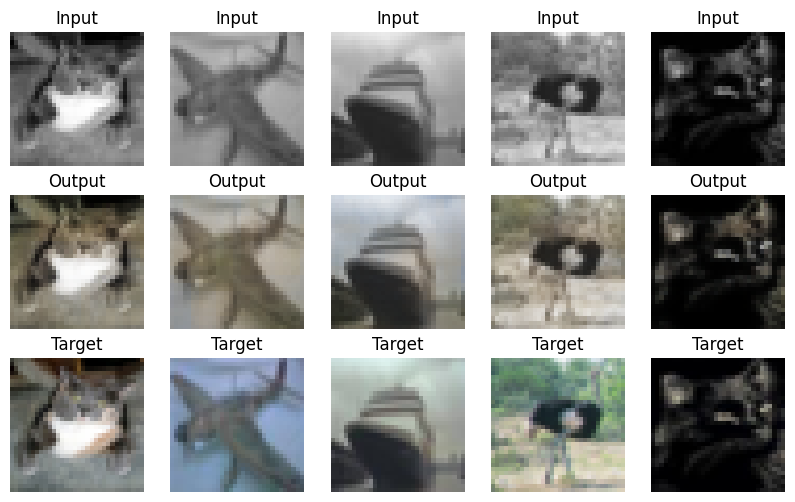

In [9]:
def denorm(x):
    return x * 0.5 + 0.5

model.eval()
images, _ = next(iter(loader))
images = images.to(device)
inputs = to_grayscale(images)

with torch.no_grad():
    outputs = model(inputs)

images = denorm(images.cpu())
inputs = denorm(inputs.cpu())
outputs = denorm(outputs.cpu())

fig, axes = plt.subplots(3, 5, figsize=(10,6))

for i in range(5):
    axes[0,i].imshow(np.transpose(inputs[i], (1,2,0)))
    axes[0,i].set_title("Input")

    axes[1,i].imshow(np.transpose(outputs[i], (1,2,0)))
    axes[1,i].set_title("Output")

    axes[2,i].imshow(np.transpose(images[i], (1,2,0)))
    axes[2,i].set_title("Target")

    for j in range(3):
        axes[j,i].axis("off")

plt.show()


In [11]:
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt
import numpy as np


img_path = '/content/download (4).jpeg'


img = Image.open(img_path).convert("RGB")


In [12]:
transform_img = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

img_tensor = transform_img(img).unsqueeze(0).to(device)


In [13]:
def to_grayscale(batch):
    gray = batch.mean(dim=1, keepdim=True)
    return gray.repeat(1, 3, 1, 1)

input_img = to_grayscale(img_tensor)


In [14]:
model.eval()
with torch.no_grad():
    output_img = model(input_img)


In [15]:
def denorm(x):
    return x * 0.5 + 0.5

inp = denorm(input_img[0].cpu())
out = denorm(output_img[0].cpu())
orig = denorm(img_tensor[0].cpu())


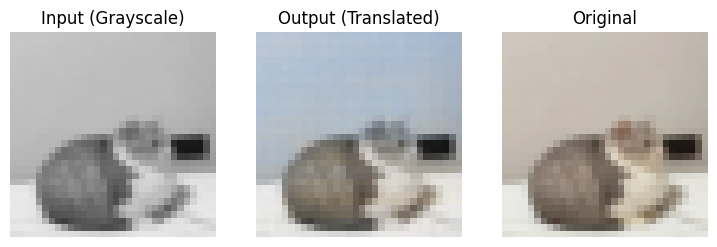

In [16]:
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(np.transpose(inp, (1,2,0)))
plt.title("Input (Grayscale)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.transpose(out, (1,2,0)))
plt.title("Output (Translated)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.transpose(orig, (1,2,0)))
plt.title("Original")
plt.axis("off")

plt.show()
